# Olist E-Commerce Operations Analytics

Delivery performance and cancellation analysis across 99,441 orders
from a Brazilian e-commerce marketplace (2016–2018).

**Tools:** Python, pandas, NumPy

**Sections:** Data loading → Validation → Delivery KPIs → State analysis
→ Seller analysis → Monthly trend → Cancellation analysis

## 1. Data Loading

Loading 7 related tables from the Olist dataset.
Note the differing grain: orders is one row per order, order_items is
one row per item, and payments is one row per payment method per order.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns',None)
orders = pd.read_csv('../data/olist_orders_dataset.csv') 

print(orders.shape)
orders.head()

(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
base = '../data/'

order_items = pd.read_csv(base + 'olist_order_items_dataset.csv')
customers = pd.read_csv(base + 'olist_customers_dataset.csv')
sellers = pd.read_csv(base + 'olist_sellers_dataset.csv')
products = pd.read_csv(base + 'olist_products_dataset.csv')
reviews = pd.read_csv(base + 'olist_order_reviews_dataset.csv')
payments = pd.read_csv(base + 'olist_order_payments_dataset.csv')

for name, df in [('orders', orders), 
                 ('order_items', order_items),
                 ('customers', customers), 
                 ('sellers', sellers),
                 ('products', products), ('reviews', reviews),
                 ('payments', payments)]:
    print(name, df.shape)

orders (99441, 8)
order_items (112650, 7)
customers (99441, 5)
sellers (3095, 4)
products (32951, 9)
reviews (99224, 7)
payments (103886, 5)


In [3]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [4]:
orders.isnull().sum() #nulls checking

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [5]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
orders[(orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].isnull())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [7]:
#changing the timestamps to datetime 
date_cols = ['order_purchase_timestamp',
             'order_approved_at',
             'order_delivered_carrier_date',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


## 3. Delivery KPIs

Delivery metrics are calculated on delivered orders only (96,478).
Cancelled and in-transit orders are excluded — an order that was never
delivered cannot be counted as a late delivery, and including them
would understate on-time performance.

Two metrics are derived from raw timestamps:
- **delivery_days** — actual delivery date minus purchase date (speed)
- **is_on_time** — actual delivery within the estimated date (reliability)

**Findings:** 91.88% on-time delivery. Average 12 days, median 10 —
right-skewed, with 63 orders (0.07%) exceeding 100 days. These were
retained as genuine long-tail cases rather than excluded.

In [8]:
#first KPI

delivered = orders[orders['order_status'] == 'delivered'].copy()

delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - 
    delivered['order_purchase_timestamp']
).dt.days

print(delivered.shape)
print(delivered['delivery_days'].describe())

(96478, 9)
count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64


In [9]:
delivered[delivered['delivery_days'] > 100].shape

(63, 9)

In [10]:
delivered['is_on_time'] = (
    delivered['order_delivered_customer_date'] <= 
    delivered['order_estimated_delivery_date']
)

on_time_pct = delivered['is_on_time'].mean() * 100


print(f"On-Time Delivery %: {on_time_pct:.2f}%")
print(delivered['is_on_time'].value_counts())

On-Time Delivery %: 91.88%
is_on_time
True     88644
False     7834
Name: count, dtype: int64


## 4. State-Level Performance

Joining customer geography to delivered orders. Row count is checked
before and after the merge (96,478 → 96,478) to confirm no duplicate
explosion from the join key.

**Findings:** On-time rates range from 76.1% (Alagoas) to 95.0%
(Paraná) — a 19-point spread.

Ranking by percentage and by volume surfaces entirely different
priorities. São Paulo has one of the best on-time rates (94.1%) but the
highest absolute count of late orders (2,394), while the worst state by
percentage accounts for fewer than 100.

Speed and reliability are also distinct: Pará averages 23.3 delivery
days yet meets 87.6% of promises, while Rio de Janeiro delivers in 14.8
days but meets only 86.5% — an estimation problem rather than a
logistics one.

In [11]:
#cust join with geo table
delivered_geo = delivered.merge( customers[['customer_id','customer_state']],
                                 on = 'customer_id',
                                 how = 'left')
print(delivered.shape,delivered_geo.shape)

(96478, 10) (96478, 11)


In [12]:
state_pref = delivered_geo.groupby('customer_state').agg( 
                   total_orders = ('order_id','count'),
                   on_time_pct = ('is_on_time','mean'),
                   avg_delivery_days = ('delivery_days','mean') 
).reset_index()
state_pref['on_time_pct'] = state_pref['on_time_pct'] * 100
state_pref = state_pref.sort_values('on_time_pct')
print(state_pref.head(10))

   customer_state  total_orders  on_time_pct  avg_delivery_days
1              AL           397    76.070529          24.040302
9              MA           717    80.334728          21.117155
16             PI           476    84.033613          18.993697
5              CE          1279    84.675528          20.817826
24             SE           335    84.776119          21.029851
4              BA          3256    85.964373          18.866400
18             RJ         12350    86.526316          14.848583
26             TO           274    87.226277          17.226277
13             PA           946    87.632135          23.316068
7              ES          1995    87.769424          15.331830


In [13]:
#ignore this writing this for better understanding
delivered_geo['promised_days'] = (
    delivered_geo['order_estimated_delivery_date'] - 
    delivered_geo['order_purchase_timestamp']
).dt.days

state_pref = delivered_geo.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    on_time_pct=('is_on_time', 'mean'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_promised_days=('promised_days', 'mean')
).reset_index()

state_pref['on_time_pct'] = state_pref['on_time_pct'] * 100
state_pref['gap'] = state_pref['avg_promised_days'] - state_pref['avg_delivery_days']

state_pref = state_pref.sort_values('on_time_pct').reset_index(drop=True)
print(state_pref.head(10).round(1))

  customer_state  total_orders  on_time_pct  avg_delivery_days  \
0             AL           397         76.1               24.0   
1             MA           717         80.3               21.1   
2             PI           476         84.0               19.0   
3             CE          1279         84.7               20.8   
4             SE           335         84.8               21.0   
5             BA          3256         86.0               18.9   
6             RJ         12350         86.5               14.8   
7             TO           274         87.2               17.2   
8             PA           946         87.6               23.3   
9             ES          1995         87.8               15.3   

   avg_promised_days   gap  
0               32.2   8.2  
1               30.1   9.0  
2               29.7  10.7  
3               31.0  10.2  
4               30.5   9.5  
5               29.1  10.2  
6               26.0  11.1  
7               28.7  11.5  
8           

In [14]:
#volume-weighted priority
state_pref['late_orders']=(state_pref['total_orders']*(100-state_pref['on_time_pct'])/100).round(0)
top_impact = state_pref.sort_values('late_orders',ascending=False).head(10)
print(top_impact.round(10))

   customer_state  total_orders  on_time_pct  avg_delivery_days  \
20             SP         40501    94.089035           8.298094   
6              RJ         12350    86.526316          14.848583   
21             MG         11354    94.389642          11.542188   
5              BA          3256    85.964373          18.866400   
17             RS          5345    92.834425          14.819237   
15             SC          3546    90.242527          14.475183   
22             PR          4923    95.003047          11.526711   
9              ES          1995    87.769424          15.331830   
3              CE          1279    84.675528          20.817826   
13             PE          1593    89.202762          17.965474   

    avg_promised_days        gap  late_orders  
20          18.776820  10.478727       2394.0  
6           25.998219  11.149636       1664.0  
21          24.187951  12.645764        637.0  
5           29.073096  10.206695        457.0  
17          28.158840 

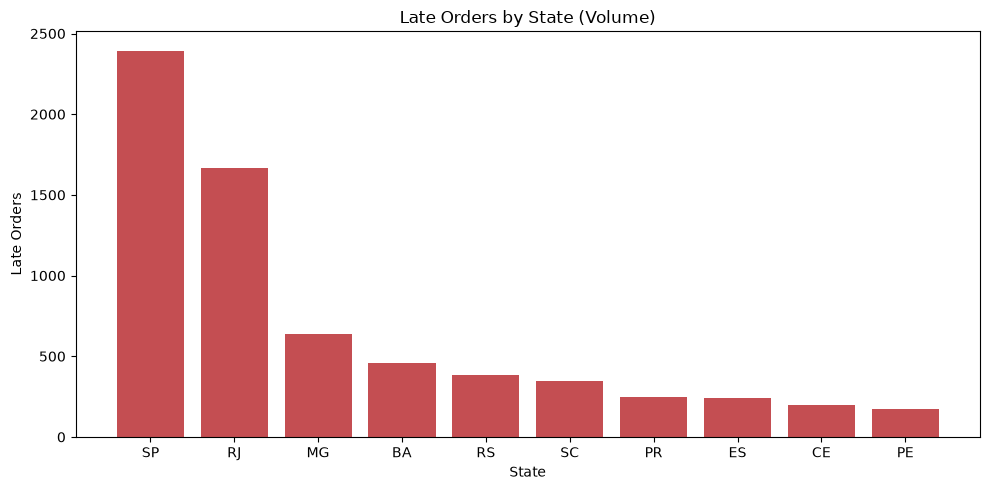

In [15]:
import matplotlib.pyplot as plt

top10 = state_pref.sort_values('late_orders', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top10['customer_state'], top10['late_orders'], color='#c44e52')

ax.set_title('Late Orders by State (Volume)')
ax.set_xlabel('State')
ax.set_ylabel('Late Orders')

plt.tight_layout()
plt.show()

## 5. Seller-Level Performance

Filtered to 462 sellers with 50+ delivered items to remove small-sample
noise (median seller handled 8 items; single-item sellers produce
on-time rates of 0% or 100%). These sellers cover 85,131 of 110,197
items — 77% of volume.

Note the grain shift: this section works at item level, not order
level, since a single order can contain items from multiple sellers.

**Finding:** The percentage-worst and volume-worst top-10 seller lists
share no sellers. The highest-impact seller has an 89.0% on-time rate —
close to average — but 214 late items, more than any seller with a
worse percentage.

In [16]:
#seller-side analysis
seller_pref = order_items.merge(
    delivered[['order_id','is_on_time','delivery_days']],
    on='order_id',
    how='inner')
print(order_items.shape,seller_pref.shape)

(112650, 7) (110197, 9)


In [17]:
print(orders.columns.tolist())
print()
print(delivered.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'is_on_time']


In [18]:
#Seller-wise aggregate:
seller_summary = seller_pref.groupby('seller_id').agg(
    total_items = ('order_item_id','count'),
    on_time_pct = ('is_on_time','mean'),
    avg_delivery_days = ('delivery_days','mean')
).reset_index()
seller_summary['on_time_pct']=seller_summary['on_time_pct']*100
seller_summary['late_items'] = (
    seller_summary['total_items'] * (100 - seller_summary['on_time_pct']) / 100
).round(0)

print(seller_summary.shape)
print(seller_summary['total_items'].describe())

(2970, 5)
count    2970.000000
mean       37.103367
std       119.672968
min         1.000000
25%         2.000000
50%         8.000000
75%        26.000000
max      1996.000000
Name: total_items, dtype: float64


In [19]:
#Threshold decide
active_sellers = seller_summary[seller_summary['total_items'] >= 50].copy()

print(f"Sellers with 50+ items: {len(active_sellers)} of {len(seller_summary)}")
print(f"Items covered: {active_sellers['total_items'].sum()} of {seller_summary['total_items'].sum()}")

worst = active_sellers.sort_values('on_time_pct').head(10)
print(worst.round(1))

Sellers with 50+ items: 462 of 2970
Items covered: 85131 of 110197
                             seller_id  total_items  on_time_pct  \
1000  54965bbe3e4f07ae045b90b0b8541f52           81         67.9   
478   2a1348e9addc1af5aaa619b1a3679d6b           51         70.6   
1141  6039e27294dc75811c0d8a39069f52c0           74         74.3   
1928  a49928bcdf77c55c6d6e05e09a9b4ca5          104         75.0   
1139  602044f2c16190c2c6e45eb35c2e21cb           55         76.4   
79    06a2c3af7b3aee5d69171b0e14f0ee87          402         76.4   
2211  beadbee30901a7f61d031b6b686095ad           68         76.5   
2365  cac4c8e7b1ca6252d8f20b2fc1a2e4af           82         76.8   
2720  ea566164622c6b439516ab18062c42cd           52         76.9   
1805  99a54764c341d5dc80b4a8fac4eba3fb           66         77.3   

      avg_delivery_days  late_items  
1000               26.2        26.0  
478                26.8        15.0  
1141               17.5        19.0  
1928               16.5        2

In [20]:
worst_by_volume = active_sellers.sort_values('late_items', ascending=False).head(10)
print(worst_by_volume.round(1))

                             seller_id  total_items  on_time_pct  \
858   4a3ca9315b744ce9f8e9374361493884         1949         89.0   
358   1f50f920176fa81dab994f9023523100         1926         90.6   
834   4869f7a5dfa277a7dca6462dcf3b52b2         1148         88.4   
188   1025f0e2d44d7041d6cf58b6550e0bfa         1420         90.8   
1480  7c67e1448b00f6e969d365cea6b010ab         1355         90.4   
1190  6560211a19b47992c3666cc44a7e94c0         1996         93.8   
2725  ea8482cd71df3c1969d7b9473ff13abc         1188         89.6   
1758  955fee9216a65b617aa5c0531780ce60         1472         91.9   
2543  da8622b14eb17ae2831f4ac5b9dab84a         1548         92.7   
2388  cc419e0650a3c5ba77189a1882b7556a         1719         94.0   

      avg_delivery_days  late_items  
858                13.9       214.0  
358                15.1       182.0  
834                14.5       133.0  
188                11.6       131.0  
1480               21.9       130.0  
1190                9.1

## 6. Monthly Trend

Aggregating on-time performance by order month to check whether the
91.88% headline figure is stable over time.

Months with fewer than 1,500 orders (Sept 2016 – Jan 2017) are excluded.
The platform was still ramping up — 2016 contained 267 orders in total,
so monthly rates would swing on single orders rather than reflect
operational performance.

**Findings:** The average masks a 20-point swing. On-time performance
ranges from 78.6% (March 2018) to 98.6% (June 2018).

Two distinct patterns emerge. November 2017 shows a dip to 85.7% on the
highest order volume in the dataset (7,289) — a capacity constraint
during Black Friday, with delivery times rising from 11.4 to 14.7 days.
February–March 2018 shows a separate degradation to 84.0% and 78.6% on
normal volume, indicating an operational rather than demand-driven
issue, followed by recovery to 94.7% in April.

In [21]:
#MONTHLY TREND
monthly = delivered.copy()
monthly['order_month'] = monthly['order_purchase_timestamp'].dt.to_period('M')
monthly_trend = monthly.groupby('order_month').agg(
    total_orders = ('order_id','count'),
    on_time_pct = ('is_on_time','mean'),
    avg_delivery_days = ('delivery_days','mean')).reset_index()
monthly_trend['on_time_pct']=monthly_trend['on_time_pct']*100
print(monthly_trend.round(1).to_string())

   order_month  total_orders  on_time_pct  avg_delivery_days
0      2016-09             1          0.0               54.0
1      2016-10           265         98.9               19.1
2      2016-12             1        100.0                4.0
3      2017-01           750         96.9               12.1
4      2017-02          1653         96.8               12.6
5      2017-03          2546         94.4               12.4
6      2017-04          2303         92.1               14.4
7      2017-05          3546         96.4               10.8
8      2017-06          3135         96.1               11.5
9      2017-07          3872         96.6               11.1
10     2017-08          4193         96.7               10.7
11     2017-09          4150         94.8               11.4
12     2017-10          4478         94.7               11.4
13     2017-11          7289         85.7               14.7
14     2017-12          5513         91.6               14.9
15     2018-01          

C:\Users\sowmya\AppData\Local\Temp\ipykernel_20728\2858901859.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(monthly_trend.round(1).to_string())


In [22]:
# Excluded months with <1,500 orders (Sept 2016 – Jan 2017) — 
# platform ramp-up period, sample too small for reliable rates

In [23]:
monthly_trend_clean = monthly_trend[monthly_trend['total_orders'] >= 1500]
print(monthly_trend_clean.round(1).to_string())

   order_month  total_orders  on_time_pct  avg_delivery_days
4      2017-02          1653         96.8               12.6
5      2017-03          2546         94.4               12.4
6      2017-04          2303         92.1               14.4
7      2017-05          3546         96.4               10.8
8      2017-06          3135         96.1               11.5
9      2017-07          3872         96.6               11.1
10     2017-08          4193         96.7               10.7
11     2017-09          4150         94.8               11.4
12     2017-10          4478         94.7               11.4
13     2017-11          7289         85.7               14.7
14     2017-12          5513         91.6               14.9
15     2018-01          7069         93.4               13.6
16     2018-02          6555         84.0               16.5
17     2018-03          7003         78.6               15.9
18     2018-04          6798         94.7               11.0
19     2018-05          

C:\Users\sowmya\AppData\Local\Temp\ipykernel_20728\3548887480.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(monthly_trend_clean.round(1).to_string())


## 7. Cancellation Analysis

Cancellation rate is calculated across all orders, not just delivered
ones — the denominator must include both cancelled and completed orders.

Note a dataset limitation: cancellation reason codes are not available,
so drivers are inferred from dimensional patterns rather than stated
causes.

**Findings:** Overall cancellation rate is 0.63% (625 of 99,441).

Geography shows minimal variation — 0.44% to 0.78% across states with
500+ orders, a 0.34-point spread. This rules out region as a driver,
in contrast to delivery performance which varied 19 points by state.

Payment method does show signal. Voucher-paid orders cancel at 3.21%
versus 0.46–0.57% for card and boleto payments — over five times the
baseline rate. The three orders with undefined payment type were all
cancelled, consistent with a payment process failure.

In [24]:
cancelled = orders[orders['order_status'] == 'canceled']

print(f"Cancelled: {len(cancelled)} of {len(orders)}")
print(f"Cancellation rate: {len(cancelled)/len(orders)*100:.2f}%")

Cancelled: 625 of 99441
Cancellation rate: 0.63%


In [25]:
cancel_geo = orders.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

cancel_geo['is_cancelled'] = cancel_geo['order_status'] == 'canceled'

state_cancel = cancel_geo.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    cancelled=('is_cancelled', 'sum'),
    cancel_rate=('is_cancelled', 'mean')
).reset_index()

state_cancel['cancel_rate'] = state_cancel['cancel_rate'] * 100
state_cancel = state_cancel[state_cancel['total_orders'] >= 500]

print(state_cancel.sort_values('cancel_rate', ascending=False).head(10).round(2))

   customer_state  total_orders  cancelled  cancel_rate
25             SP         41746        327         0.78
18             RJ         12852         86         0.67
8              GO          2020         13         0.64
10             MG         11635         64         0.55
9              MA           747          4         0.54
5              CE          1336          7         0.52
23             SC          3637         19         0.52
4              BA          3380         16         0.47
22             RS          5466         25         0.46
7              ES          2033          9         0.44


In [26]:
pay_cancel = orders.merge(
    payments[['order_id', 'payment_type']].drop_duplicates('order_id'),
    on='order_id',
    how='left'
)

pay_cancel['is_cancelled'] = pay_cancel['order_status'] == 'canceled'

print(pay_cancel.groupby('payment_type').agg(
    total_orders=('order_id', 'count'),
    cancelled=('is_cancelled', 'sum'),
    cancel_rate=('is_cancelled', 'mean')
).round(4))

              total_orders  cancelled  cancel_rate
payment_type                                      
boleto               19784         95       0.0048
credit_card          75387        432       0.0057
debit_card            1527          7       0.0046
not_defined              3          3       1.0000
voucher               2739         88       0.0321
